<a href="https://colab.research.google.com/github/saxena431/Sareni2/blob/main/Nazira_New_wala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pip install python-docx

In [ ]:
df1=pd.read_excel("/content/call 11-3.xlsx")
df3=pd.read_excel("/content/telecaller list 03-10.xlsx")
df4=pd.read_excel("/content/Overall_Calling.xlsx")

In [ ]:
df2=df1[["Response","Date","Caller"]]

In [ ]:
mapping_dict = {
    "Busy": "Not Connected",
    "Call Not Pick": "Not Connected",
    "Correct": "Positive",
    "Invalid No": "Not Connected",
    "Negative": "Negative",
    "No Incoming Call": "Not Connected",
    "No Response": "Not Decided",
    "Not Decided": "Not Decided",
    "Out of Coverage": "Not Connected",
    "Positive": "Positive",
    "Switch Off": "Not Connected",
    "Wrong No": "Wrong No"
}

In [ ]:
df2["Calling_Responses2"]=df2["Response"].map(mapping_dict)
df4["Calling_All"]=df4["Calling"].map(mapping_dict)

/tmp/ipykernel_626/1600893660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Calling_Responses2"]=df2["Response"].map(mapping_dict)


In [ ]:
df5 = pd.concat([df4["Calling_All"], df2["Calling_Responses2"]], ignore_index=True)


In [ ]:
df2["Caller2"]=df2["Caller"].map(df3.set_index("Id")["Name"])

/tmp/ipykernel_626/3619921227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Caller2"]=df2["Caller"].map(df3.set_index("Id")["Name"])


In [ ]:
pivot = df2.pivot_table(
    index="Caller2",
    columns="Calling_Responses2",
    values="Response",  # the column to count
    aggfunc='count',
    fill_value=0
)

In [ ]:
pivot = pivot.reset_index()

# -----------------------------
# Move Positive column to 2nd position
# -----------------------------
cols = list(pivot.columns)
cols.remove("Positive")
cols.insert(1, "Positive")
pivot = pivot[cols]

# -----------------------------
# Add Grand Total column for each row
# -----------------------------
pivot["Grand Total"] = pivot.select_dtypes(include="number").sum(axis=1)

# -----------------------------
# Create Grand Total row
# -----------------------------
grand_total = pivot.select_dtypes(include="number").sum()
grand_total["Caller2"] = "Grand Total"

# Append row
pivot = pd.concat([pivot, pd.DataFrame([grand_total])], ignore_index=True)

pivot

Calling_Responses2,Caller2,Positive,Negative,Not Connected,Not Decided,Grand Total
0,Ananta kataky,90,1,88,3,182
1,RahulBorah,50,0,47,17,114
2,Rituraj,93,66,60,8,227
3,kiran,1,0,2,0,3
4,Grand Total,234,67,197,28,526


In [ ]:
pivot_df5 = df5.value_counts().reset_index()

pivot_df5.columns = ["Response", "Count"]

In [ ]:
pivot_df5["Percentage"] = (pivot_df5["Count"] / pivot_df5["Count"].sum() * 100).round(2)

In [ ]:
# Step 1: select only the responses of interest
cols_Overall = ["Positive", "Negative", "Not Decided"]

# Filter pivot_df5 for these responses
filtered = pivot_df5[pivot_df5["Response"].isin(cols_Overall)].copy()

# Step 2: calculate total percentage
total_counts = filtered["Count"].sum()

# Step 3: calculate percentage of each selected response
filtered["Percentage"] = (filtered["Count"] / total_counts * 100).round(2)

# Step 4: reset index (optional)
df_total_percent2 = filtered[["Response", "Percentage"]].reset_index(drop=True)

print(df_total_percent2)

      Response  Percentage
0     Positive       74.94
1     Negative       15.64
2  Not Decided        9.42


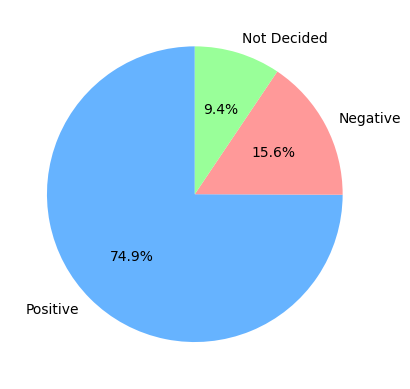

In [ ]:
plt.pie(
    df_total_percent2["Percentage"],
    labels=df_total_percent2["Response"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff","#ff9999","#99ff99"]
)
plt.savefig("chart2.png", bbox_inches='tight')

In [ ]:
# # isme add
# counts = df5.value_counts()
# summary_transposed = counts.to_frame().T  # .T transposes
# summary_transposed.index = ["Total_Count"]  # optional row name
# summary_transposed=summary_transposed.reset_index()
# print(summary_transposed)

In [ ]:
# Count values
counts = df5.value_counts()

# Convert to dataframe and transpose
summary_transposed = counts.to_frame().T

# Add Grand Total column
summary_transposed["Grand Total"] = summary_transposed.sum(axis=1)

# Add dummy columns
summary_transposed["Total Caller"] = ""
summary_transposed["Day"] = ""

# Reorder columns
summary_transposed = summary_transposed[
    ["Total Caller","Day","Positive","Not Connected","Negative","Not Decided","Wrong No","Grand Total"]
]

print(summary_transposed)

      Total Caller Day  Positive  Not Connected  Negative  Not Decided  \
count                        891            884       186          112   

       Wrong No  Grand Total  
count         6         2079  


In [ ]:
# Step 1: select columns
cols = ["Positive", "Negative", "Not Decided"]


column_totals = pivot[cols].sum()

total = column_totals.sum()


percentages = (column_totals / total * 100).round(2)


df_total_percent = percentages.reset_index()
df_total_percent.columns = ["Response", "Percentage"]

print(df_total_percent)

      Response  Percentage
0     Positive       71.12
1     Negative       20.36
2  Not Decided        8.51


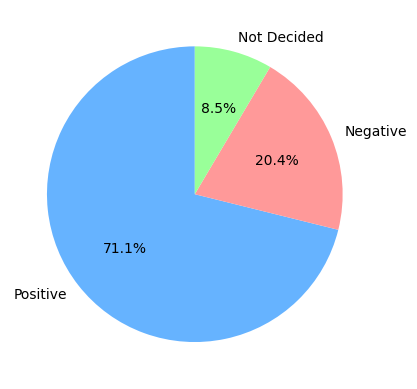

In [ ]:
plt.pie(
    df_total_percent["Percentage"],
    labels=df_total_percent["Response"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff","#ff9999","#99ff99"]
)
plt.savefig("chart.png", bbox_inches='tight')

In [ ]:
# from docx import Document
# from docx.shared import Inches, Pt
# from docx.enum.text import WD_PARAGRAPH_ALIGNMENT

# # -----------------------------
# # Create Word Document
# # -----------------------------
# doc = Document()

# # -----------------------------
# # PAGE 1 : Response Analysis
# # -----------------------------
# title = doc.add_paragraph("Response Analysis")
# title.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
# title.runs[0].font.size = Pt(16)
# title.runs[0].bold = True

# doc.add_paragraph()

# # Insert first chart
# img_paragraph = doc.add_paragraph()
# img_paragraph.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
# img_run = img_paragraph.add_run()
# img_run.add_picture("chart.png", width=Inches(4))

# doc.add_paragraph()
# doc.add_paragraph()

# # -----------------------------
# # Add Pivot Table
# # -----------------------------
# table = doc.add_table(rows=1, cols=len(pivot.columns))
# table.style = 'Table Grid'

# # Header
# hdr_cells = table.rows[0].cells
# for i, col_name in enumerate(pivot.columns):
#     hdr_cells[i].text = str(col_name)
#     hdr_cells[i].paragraphs[0].alignment = WD_PARAGRAPH_ALIGNMENT.CENTER

# # Data rows
# for _, row in pivot.iterrows():
#     row_cells = table.add_row().cells
#     for i, col_name in enumerate(pivot.columns):
#         row_cells[i].text = str(row[col_name])
#         row_cells[i].paragraphs[0].alignment = WD_PARAGRAPH_ALIGNMENT.CENTER


# # -----------------------------
# # PAGE 2 : Overall Analysis
# # -----------------------------
# doc.add_page_break()

# heading = doc.add_paragraph("Overall Analysis")
# heading.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
# heading.runs[0].font.size = Pt(16)
# heading.runs[0].bold = True

# doc.add_paragraph()

# # Insert second chart
# img_paragraph2 = doc.add_paragraph()
# img_paragraph2.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
# img_run2 = img_paragraph2.add_run()
# img_run2.add_picture("chart2.png", width=Inches(4))

# doc.add_paragraph()
# doc.add_paragraph()


# # -----------------------------
# # Create Summary Table
# # -----------------------------
# # Example summary dataframe (you already created it)
# # summary_transposed example structure:
# # index | Not Connected | Positive | Negative | Not Decided | Wrong No
# # Total_Count | 687 | 658 | 119 | 84 | 6

# summary_transposed = summary_transposed.reset_index()

# rows = summary_transposed.shape[0]
# cols = summary_transposed.shape[1]

# second_table = doc.add_table(rows=rows + 1, cols=cols)
# second_table.style = 'Table Grid'

# # Header row
# for j, col_name in enumerate(summary_transposed.columns):
#     second_table.cell(0, j).text = str(col_name)
#     second_table.cell(0, j).paragraphs[0].alignment = WD_PARAGRAPH_ALIGNMENT.CENTER

# # Data rows
# for i in range(rows):
#     for j in range(cols):
#         second_table.cell(i + 1, j).text = str(summary_transposed.iloc[i, j])
#         second_table.cell(i + 1, j).paragraphs[0].alignment = WD_PARAGRAPH_ALIGNMENT.CENTER


# # -----------------------------
# # Save Word File
# # -----------------------------
# doc.save("Response_Analysis_with_Overall_Counts.docx")

# print("Word file created successfully: Response_Analysis_with_Overall_Counts.docx")

In [ ]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT

# Load template
doc = Document("Nizamabad Municipal Corporation Report_10-3.docx")

# -----------------------------
# PAGE 1 : Response Analysis
# -----------------------------
title = doc.add_paragraph("Call Center Report(11-03-2026)")
title.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
title.runs[0].font.size = Pt(36)
title.runs[0].bold = True

doc.add_paragraph()

img_paragraph = doc.add_paragraph()
img_paragraph.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
img_paragraph.add_run().add_picture("chart.png", width=Inches(4))

doc.add_paragraph()

# Pivot table
table = doc.add_table(rows=1, cols=len(pivot.columns))
table.style = "Table Grid"

for i, col in enumerate(pivot.columns):
    table.rows[0].cells[i].text = str(col)

for _, row in pivot.iterrows():
    row_cells = table.add_row().cells
    for i, col in enumerate(pivot.columns):
        row_cells[i].text = str(row[col])

# -----------------------------
# PAGE 2 : Overall Analysis
# -----------------------------
heading = doc.add_paragraph("Overall Call Response")
heading.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
heading.runs[0].font.size = Pt(36)
heading.runs[0].bold = True

doc.add_paragraph()

img_paragraph2 = doc.add_paragraph()
img_paragraph2.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
img_paragraph2.add_run().add_picture("chart2.png", width=Inches(4))

doc.add_paragraph()

# Summary table
summary_transposed = summary_transposed.reset_index()

rows = summary_transposed.shape[0]
cols = summary_transposed.shape[1]

table2 = doc.add_table(rows=rows+1, cols=cols)
table2.style = "Table Grid"

for j, col in enumerate(summary_transposed.columns):
    table2.cell(0, j).text = str(col)

for i in range(rows):
    for j in range(cols):
        table2.cell(i+1, j).text = str(summary_transposed.iloc[i, j])

# Save
doc.save("Nazira_Report.docx")